In [47]:
import pysam, pandas, seaborn, re, scipy
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

In [4]:
class sv:
    def __init__(self, chromosome, sv_location_on_ref, sv_sequence, sv_type, supported_reads, sv_len, sv_percise, sv_name):
        self.chromosome = chromosome
        self.sv_location_on_ref = sv_location_on_ref
        self.sv_sequence = sv_sequence
        self.sv_type = sv_type
        self.supported_reads = supported_reads
        self.sv_len = sv_len
        self.sv_percise = sv_percise
        self.sv_name = sv_name 
    def display_info(self):
        print(f"sv: {self.chromosome} {self.sv_location_on_ref} {self.sv_sequence} {self.sv_type} {self.supported_reads} {self.sv_len}")


In [5]:
def get_base_modification_dictionary(
    bam_file, ref_seq, chromosome, phase_region,
):
    """
    This is for the first time phasing within SNP phased block
    Return value: a dictionary that contains cpg location and its haplotype related base modification score
    """
    methylation_identifier_0 = ('C', 0, 'm') # We only care about 5mc!!!
    methylation_identifier_1 = ('C', 1, 'm')
    phase_region_start = phase_region[0]
    phase_region_end = phase_region[1]

    phased_block_ref = ref_seq.fetch(
        chromosome, phase_region_start, phase_region_end)
    cg_loc = [
        m.start(0) for m in re.finditer("CG", str(phased_block_ref))
    ]  # Use regular expression to find all CpG locations on the reference
    # record G locatioon of 'CG's
    cg_loc = [x + phase_region_start + 1 for x in cg_loc]
    hp_myth_dict = dict()
    """
        Data structure:
        {i:[]} 
            i: CpG locations
            []: per haplotype base modification score, max 255
        Use dictionary so that when querying CpG locations the time complexity is O(1)
    """
    for i in cg_loc:
        # build the dictionary
        hp_myth_dict.update({i: [[],0]})
    phased_block_alignment = bam_file.fetch(
        chromosome, phase_region[0], phase_region[1], multiple_iterators=True
    )

    for reads in phased_block_alignment:
        read_base_ref_loc = reads.get_reference_positions(full_length=True)  
        # use full_length=True or the positions won't match
        mm = (reads.modified_bases)
        # mm is a dictionary that contains {score type: [(location, score)]}. score is 255-based
        if (mm != -1) and (mm != {}):  # update base modification scores list
            if methylation_identifier_0 in list(mm.keys()):
                methylation_identifier = methylation_identifier_0
            elif methylation_identifier_1 in list(mm.keys()):
                methylation_identifier = methylation_identifier_1
            for i in mm[methylation_identifier]:  # Remora only output one type of score: c 1 m/c 0 m, but this part can be improved for other methlyation callers
                if read_base_ref_loc[i[0]]:  # i format: (loc, score)
                    if reads.is_forward:  # cg/gc on forward and reverse reads
                        mm_ref_loc = read_base_ref_loc[i[0]] + 1
                    else:
                        mm_ref_loc = read_base_ref_loc[i[0]]
                    if mm_ref_loc in hp_myth_dict.keys():                       
                        modification_chance = i[1]  # 0 - 255 base d
                        hp_myth_dict[mm_ref_loc][0].append(modification_chance)
        for i in read_base_ref_loc:
            if i in hp_myth_dict.keys():  # O(1) search
                hp_myth_dict[i][1] += 1 
    return hp_myth_dict

In [6]:
def find_consecutive_sequences(nums, sv_len):
    # print(nums)
    # An elegent function written by ChatGPT with my modifications and improvements. 
    if not nums:
        return  None, None# Return if the list is empty
    min_diff = float('inf') 
    min_sv_index = -1
    min_sv_seq = None
    
    start = 0  # Starting index of a consecutive sequence
    number_index_pair_dict = {}
    for i in range(len(nums) - 1):
        if nums[i] + 1 != nums[i + 1]:
            if i != start:  # Check if it's not a single number sequence
                # print(f"Consecutive numbers: {nums[start:i+1]} at indexes {start} to {i}")
                current_diff = abs(sv_len - len(nums[start:i+1]))
                if current_diff < min_diff:
                    min_diff = current_diff
                    min_sv_index = start
                    min_sv_seq = nums[start:i+1]
            start = i + 1
    # Check the last sequence or a single last number
    if start < len(nums) - 1 or nums[-2] + 1 == nums[-1]:
        current_diff = abs(sv_len - len(nums[start:i+1]))
        if current_diff < min_diff:
            min_diff = current_diff
            min_sv_index = start
            min_sv_seq = nums[start:i+1]
    if min_sv_seq:
        return len(min_sv_seq), min_sv_index
    else:
        return None, None

In [7]:
def find_longest_gap(numbers, sv_size):
    min_diff = float('inf')
    min_diff_index = -1
    min_diff_sv_len = -1
    numbers_compact = [i for i in numbers if i]
    for i in range(1, len(numbers_compact)):
        gap = numbers_compact[i] - numbers_compact[i - 1]
        if abs(gap - sv_size) < min_diff:
            min_diff = abs(gap - sv_size)
            min_diff_index = i
            min_diff_sv_len = gap
    return min_diff_sv_len, numbers.index(numbers_compact[min_diff_index])


In [8]:
def get_sv_region(structural_variant: sv, reads_bam, sv_discover_range = 500):
    first_pos_on_ref = float('inf')
    last_pos_on_ref = -1
    structural_variant.sv_len = abs(int(structural_variant.sv_len))
    ref_sv_search_start = structural_variant.sv_location_on_ref - sv_discover_range
    ref_sv_search_end = ref_sv_search_start + 2 * sv_discover_range + structural_variant.sv_len if structural_variant.sv_type=='DEL' else ref_sv_search_start + 2 * sv_discover_range 
    for reads in reads_bam.fetch(structural_variant.chromosome, structural_variant.sv_location_on_ref, structural_variant.sv_location_on_ref+1):
        if reads.query_name in structural_variant.supported_reads:
            # print(reads.query_name)
            read_base_ref_loc = reads.get_reference_positions(full_length=True)
            read_base_ref_loc_no_none = [i for i in read_base_ref_loc if i]
            sv_start_index_on_reads = read_base_ref_loc.index(min(read_base_ref_loc_no_none, key=lambda x: abs(x - ref_sv_search_start)))
            sv_end_index_on_reads = read_base_ref_loc.index(min(read_base_ref_loc_no_none, key=lambda x: abs(x - ref_sv_search_end)))
            start_candidates = read_base_ref_loc[sv_start_index_on_reads : sv_end_index_on_reads]
            if structural_variant.sv_type == "INS":
                indices = [i for i, x in enumerate(start_candidates) if x == None] # all locations with gap
                # print(start_candidates)
                if len(indices) >= 2:
                    longest_len, longest_sv_start = find_consecutive_sequences(indices, int(structural_variant.sv_len))
                    if longest_len != None:
                        longest_sv_start = indices[longest_sv_start]-1 
                        longest_sv_end = longest_sv_start + longest_len + 1
                        # print(longest_sv_start, longest_sv_end)
                        # print(start_candidates[longest_sv_start], start_candidates[longest_sv_end])
                        read_sv_start_index = start_candidates[longest_sv_start]
                        read_sv_end_index = start_candidates[longest_sv_end]
            elif structural_variant.sv_type == "DEL" and len(start_candidates) > 1:
                longest_len, longest_sv_start = find_longest_gap(start_candidates, structural_variant.sv_len)
                # print(start_candidates, longest_len, longest_sv_start)
                read_sv_start_index = start_candidates[longest_sv_start]
                read_sv_end_index = start_candidates[longest_sv_start+1]
            # print(read_base_ref_loc)
            # print(read_sv_start_index, read_sv_end_index)
            if read_sv_start_index and read_sv_start_index < first_pos_on_ref:
                first_pos_on_ref = read_sv_start_index
            if read_sv_end_index and read_sv_end_index > last_pos_on_ref:
                last_pos_on_ref = read_sv_end_index
    return first_pos_on_ref, last_pos_on_ref

In [9]:
def get_sv_list(sniffles_vcf):
    sv_list = []
    for vcf_record in sniffles_vcf.fetch():
        vcf_record_list = str(vcf_record).split("\t")
        chromosome = vcf_record.chrom
        sv_location_on_ref = vcf_record.pos
        sv_sequence = vcf_record.alts
        svinfo_dict = {}
        for svinfo in vcf_record_list[7].split(";"):
            svinfo_list = svinfo.split("=")
            svinfo_dict.update({svinfo_list[0]:svinfo_list[1]} if len(svinfo_list) > 1 else {svinfo_list[0]:None})
        sv_type = svinfo_dict['SVTYPE']
        if sv_type == 'BND':
            continue
        supported_reads = svinfo_dict['RNAMES'].split(',')
        sv_len = svinfo_dict['SVLEN']
        sv_percise = vcf_record_list[7].split(";")[0]
        sv_name = vcf_record.id
        current_sv = sv(chromosome, sv_location_on_ref, sv_sequence, sv_type, supported_reads, sv_len, sv_percise, sv_name)
        sv_list.append(current_sv)
    return sv_list

In [10]:
def get_isolated_svs(mosaic_svs, germline_svs, min_discovery_region=100, min_length=250, min_support_reads_num=10):
    filtered_sv_list = []
    for m_sv in mosaic_svs:
        is_isolated = True
        for j_sv in mosaic_svs: 
            sv_distance = abs(j_sv.sv_location_on_ref - m_sv.sv_location_on_ref)
            if sv_distance <= min_discovery_region and sv_distance > 0:
                is_isolated = False
                # break  # Break out of the loop if a close SV is found, no need to check further
        if is_isolated:
            for g_sv in germline_svs:
                sv_distance = abs(g_sv.sv_location_on_ref - m_sv.sv_location_on_ref)
                if sv_distance <= min_discovery_region:
                    is_isolated = False
                    break  # Break once a matching germline SV is found and added
        if is_isolated:
            filtered_sv_list.append(m_sv)
    mosaic_sv_filtered = [sv for sv in filtered_sv_list if int(sv.sv_len) >= min_length and len(sv.supported_reads) >= min_support_reads_num]

    return mosaic_sv_filtered


In [11]:
def get_read_modification_on_sv(reads_bam, structural_variant:sv, sv_discover_range = 500, sv_comparison_range_list = [50, 100, 500, 1000, 1500, 2000]):
    read_methylation_dict = {}
    for reads in reads_bam.fetch(structural_variant.chromosome, structural_variant.sv_location_on_ref, structural_variant.sv_location_on_ref+1):
        if reads.query_name in structural_variant.supported_reads:
            read_modified_bases = reads.modified_bases
            if read_modified_bases:
                read_base_ref_loc = reads.get_reference_positions(full_length=True)
                i = structural_variant.sv_location_on_ref-sv_discover_range
                structural_variant.sv_len = abs(int(structural_variant.sv_len))

                while True:
                    if i in read_base_ref_loc:
                        region_start_index_on_read = read_base_ref_loc.index(i)
                        start_candidates = read_base_ref_loc[region_start_index_on_read : region_start_index_on_read + sv_discover_range * 2 + structural_variant.sv_len]
                        # start candidate on reads
                        break
                    else:
                        i += 1
                if structural_variant.sv_type == "INS":
                    indices = [i for i, x in enumerate(start_candidates) if x == None]
                    if len(indices) >= 2:
                        longest_len, longest_sv_start = find_consecutive_sequences(indices, int(structural_variant.sv_len))
                        if longest_len != None:
                            longest_sv_end = longest_sv_start + longest_len
                            read_sv_start_index = read_base_ref_loc.index(start_candidates[longest_sv_start])
                            read_sv_end_index = read_base_ref_loc.index(start_candidates[longest_sv_end])
                            ins_methylaion_list = [i for i in read_modified_bases[list(read_modified_bases.keys())[0]] if i[0] >= read_sv_start_index and i[0] <= read_sv_end_index]
                            for sv_comparison_range in sv_comparison_range_list:
                                extended_methylation_list = [i for i in read_modified_bases[list(read_modified_bases.keys())[0]] if (i[0] >= read_sv_start_index - sv_comparison_range and i[0] <= read_sv_start_index) or (i[0] >= read_sv_end_index and i[0] <= read_sv_end_index + sv_comparison_range)]
                                if reads.query_name not in read_methylation_dict.keys():
                                    read_methylation_dict.update({reads.query_name:[ins_methylaion_list, extended_methylation_list]})
                                else:
                                    read_methylation_dict[reads.query_name].append(extended_methylation_list)
                elif structural_variant.sv_type == "DEL":
                    longest_len, longest_sv_start = find_longest_gap(start_candidates, structural_variant.sv_len)
                    read_sv_start_index = read_base_ref_loc.index(start_candidates[longest_sv_start])
                    read_sv_end_index = read_base_ref_loc.index(start_candidates[longest_sv_start+1])
                    for sv_comparison_range in sv_comparison_range_list:
                        extended_methylation_list = [i for i in read_modified_bases[list(read_modified_bases.keys())[0]] if (i[0] >= read_sv_start_index - sv_comparison_range and i[0] <= read_sv_start_index) or (i[0] >= read_sv_end_index and i[0] <= read_sv_end_index + sv_comparison_range)]
                        if reads.query_name not in read_methylation_dict.keys():
                            read_methylation_dict.update({reads.query_name:[[(-1,-1)], extended_methylation_list]})
                        else:
                            read_methylation_dict[reads.query_name].append(extended_methylation_list)
    
    return read_methylation_dict

In [12]:
def compare_different_reads_groups(reads_bam, structural_variant:sv, ref_seq, sv_discover_range = 500, cpg_discover_range = 1000):
    first_pos_on_ref, last_pos_on_ref = get_sv_region(structural_variant, reads_bam, sv_discover_range = sv_discover_range)
    if first_pos_on_ref == float('inf'):
        print(False)
        return -1, (-1, -1)
    reads_with_sv = structural_variant.supported_reads
    methylation_identifier_0 = ('C', 0, 'm') 
    methylation_identifier_1 = ('C', 1, 'm')
    phase_region_start = first_pos_on_ref - cpg_discover_range
    phase_region_end = last_pos_on_ref + cpg_discover_range
    # print(structural_variant.chromosome, phase_region_start, phase_region_end)
    phased_block_ref = ref_seq.fetch(structural_variant.chromosome, phase_region_start, phase_region_end)
    cg_loc = [m.start(0) for m in re.finditer("CG", str(phased_block_ref))]  
    # Use regular expression to find all CpG locations on the reference
    # record G locatioon of 'CG's
    cg_loc = [x + phase_region_start + 1 for x in cg_loc]
    hp_meth_dict_reads = dict()
    # hp_meth_dict_non_sv_reads = dict()
    """
        Data structure:
        {i:[[], [], coverage_sv, coverage_non_sv]} 
            i: CpG locations
            [[], []]: per haplotype base modification score, max 255
        Use dictionary so that when querying CpG locations the time complexity is O(1)
    """
    for i in cg_loc:
        # build the dictionary
        hp_meth_dict_reads.update({i: [[],[], 0, 0]})
        # hp_meth_dict_non_sv_reads.update({i: [[],0]})
    phased_block_alignment = reads_bam.fetch(structural_variant.chromosome, phase_region_start, phase_region_end, multiple_iterators=True)
    # print(chromosome, phase_region_start, phase_region_end)
    for reads in (phased_block_alignment):
        # print(reads.query_name)
        read_base_ref_loc = reads.get_reference_positions(full_length=True)  
        # use full_length=True or the positions won't match
        mm = (reads.modified_bases)
        # print(mm)
        # mm is a dictionary that contains {score type: [(location, score)]}. score is 255-based
        if (mm != -1) and (mm != {}):  # update base modification scores list
            # print(True)
            if methylation_identifier_0 in list(mm.keys()):
                methylation_identifier = methylation_identifier_0
            elif methylation_identifier_1 in list(mm.keys()):
                methylation_identifier = methylation_identifier_1
            for i in mm[methylation_identifier]:  # Remora only output one type of score: c 1 m/c 0 m, but this part can be improved for other methlyation callers
                if read_base_ref_loc[i[0]]:  # i format: (loc, score)
                    if reads.is_forward:  # cg/gc on forward and reverse reads
                        mm_ref_loc = read_base_ref_loc[i[0]] + 1
                    else:
                        mm_ref_loc = read_base_ref_loc[i[0]]
                    if reads.query_name in structural_variant.supported_reads:
                        if mm_ref_loc in hp_meth_dict_reads.keys():                       
                            modification_chance = i[1]  # 0 - 255 based
                            hp_meth_dict_reads[mm_ref_loc][0].append(modification_chance)
                    else:
                        if mm_ref_loc in hp_meth_dict_reads.keys():                       
                            modification_chance = i[1]  # 0 - 255 based
                            hp_meth_dict_reads[mm_ref_loc][1].append(modification_chance)
        for i in read_base_ref_loc:
            if reads.query_name in structural_variant.supported_reads:
                if i in hp_meth_dict_reads.keys():  # O(1) search
                    hp_meth_dict_reads[i][2] += 1 
            else:
                if i in hp_meth_dict_reads.keys():  # O(1) search
                    hp_meth_dict_reads[i][3] += 1 
    return hp_meth_dict_reads, (phase_region_start, phase_region_end)

In [13]:
def get_cloest_value_perc(input_list, search_number):
    closest_number = min(input_list, key=lambda x: abs(x - search_number))
    closest_index = input_list.index(closest_number)
    closest_perc = closest_index/len(input_list)
    return closest_perc

In [14]:
ftx_mosaic_vcf = pysam.VariantFile("./sv_bam_vcf/brain_FTX_400x_chr22_mosaic.vcf.gz") 
ftx_germline_vcf = pysam.VariantFile("./sv_bam_vcf/brain_FTX_400x_chr22_germline.vcf.gz")
hapmap_mosaic_vcf = pysam.VariantFile("./hapmap_sv/hapmap_smaht_ont_mosaic.vcf.gz")
hapmap_germline_vcf = pysam.VariantFile("./hapmap_sv/hapmap_smaht_ont.vcf.gz")
hapmap_reference = pysam.Fastafile("/stornext/snfs4/next-gen/scratch/luis/references/human-grch38.fasta")
hapmap_chr1_bam = pysam.AlignmentFile("./hapmap.chr1.primary.bam")
reads_bam = pysam.AlignmentFile("./brain_FTX_400x_chr22.primary.bam")
reference_genome = pysam.Fastafile("/stornext/snfs4/next-gen/scratch/luis/references/human-grch38_alts.fasta.gz")


[W::hts_idx_load3] The index file is older than the data file: ./brain_FTX_400x_chr22.primary.bam.bai


In [15]:
hapmap_mosaic_sv_list = get_sv_list(hapmap_mosaic_vcf)
hapmap_germline_sv_list = get_sv_list(hapmap_germline_vcf)
hapmap_all_isolated_mosaic_sv = get_isolated_svs(hapmap_mosaic_sv_list, hapmap_germline_sv_list, min_discovery_region=300)
hapmap_all_isolated_germline_sv = get_isolated_svs(hapmap_germline_sv_list, hapmap_mosaic_sv_list, min_discovery_region=300)

hapmap_mosaic_sv_ins_list = [i for i in hapmap_mosaic_sv_list if i.sv_type == 'INS' and int(i.sv_len) >= 250 and len(i.supported_reads) >= 20]
hapmap_mosaic_sv_del_list = [i for i in hapmap_mosaic_sv_list if i.sv_type == "DEL" and abs(int(i.sv_len)) >= 250 and len(i.supported_reads) >= 20]


In [16]:
len(hapmap_mosaic_sv_ins_list), len(hapmap_mosaic_sv_del_list), len(hapmap_germline_sv_list), len(hapmap_all_isolated_mosaic_sv), len(hapmap_all_isolated_germline_sv)

(121, 136, 30104, 266, 4007)

In [18]:
len([i for i in hapmap_germline_sv_list if i.sv_type == 'INS' ]), len([i for i in hapmap_germline_sv_list if i.sv_type == "DEL"])

(16564, 13460)

In [17]:
ftx_mosaic_sv_list = get_sv_list(ftx_mosaic_vcf)
ftx_germline_sv_list = get_sv_list(ftx_germline_vcf)
ftx_all_isolated_mosaic_sv = get_isolated_svs(ftx_mosaic_sv_list, ftx_germline_sv_list, min_discovery_region=300)
ftx_mosaic_sv_ins_list = [i for i in ftx_mosaic_sv_list if i.sv_type == 'INS' and int(i.sv_len) >= 200 and len(i.supported_reads) >= 10]
ftx_mosaic_sv_del_list = [i for i in ftx_mosaic_sv_list if i.sv_type == "DEL" and abs(int(i.sv_len)) >= 200 and len(i.supported_reads) >= 10]
ftx_all_isolated_germline_sv = get_isolated_svs(ftx_germline_sv_list, ftx_mosaic_sv_list, min_discovery_region=300)

len(ftx_mosaic_sv_ins_list), len(ftx_mosaic_sv_del_list), len(ftx_germline_sv_list), len(ftx_all_isolated_mosaic_sv), len(ftx_all_isolated_germline_sv)


(47, 32, 596, 6, 75)

In [19]:
ftx_isolated_germline_sv_ins_list = [i for i in ftx_all_isolated_germline_sv if i.sv_type == 'INS' and int(i.sv_len) >= 250 and len(i.supported_reads) >= 20]

In [20]:
len(ftx_isolated_germline_sv_ins_list)

71

In [21]:
sv_comparison_range_list = [50, 100, 200, 500, 1000, 1500, 2000]
# current_sv = sv_ins_list[10]
with PdfPages('sv_ftx_isolated_germline_ins_methylation_germline_plots.pdf') as pdf:
    for current_sv in tqdm(ftx_isolated_germline_sv_ins_list):
        read_methylation_renge_dict_dict = get_read_modification_on_sv(reads_bam, current_sv, sv_comparison_range_list = sv_comparison_range_list)
        sv_methylation_df = pandas.DataFrame(columns=["read_name", "sv_type", "CpG num on SV", "methylation_on_sv"] + sv_comparison_range_list)
        sv_methylation_dict = {}
        '''
            read_svs_modifications_dict[0] data structure:
            {
            read_name: [[(sv methylation loc, methylation score), (), ...], [(flank 1 methylation loc, methylation score), (), ...], [(flank 2 methylation loc, methylation score), (), ...]],
            ...
            }
        '''
        for i in read_methylation_renge_dict_dict.items():
            if i[1][0] != [] and i[1][1] != []:
                methylation_num_on_sv = []
                read_name = i[0]
                sv_methylation_mean = numpy.mean([j[1] for j in i[1][0]])
                methylation_num_on_sv.append(len(i[1][0]))
                for k in i[1][1:]:
                    flank_methylation_mean = numpy.mean([j[1] for j in k])
                    if read_name not in sv_methylation_dict.keys():
                        sv_methylation_dict.update({read_name:['INS', numpy.mean(methylation_num_on_sv), sv_methylation_mean, flank_methylation_mean]})
                    else:
                        sv_methylation_dict[read_name].append(flank_methylation_mean)
        # sv_methylation_dict
        rows = [[key] + value for key, value in sv_methylation_dict.items()]
        sv_methylation_df = pandas.DataFrame(rows, columns=["read_name", "sv_type", "CpG num on SV", "methylation_on_sv"]+sv_comparison_range_list).set_index('read_name')
        mean_methylation_num_on_sv = numpy.mean(sv_methylation_df["CpG num on SV"])
        if mean_methylation_num_on_sv > 10:
            plt.figure(figsize=(20, 20))
            # print(current_sv.sv_len, current_sv.sv_location_on_ref, len(current_sv.supported_reads), numpy.mean(sv_methylation_df["CpG num on SV"]))
            ax = seaborn.heatmap(sv_methylation_df.drop(['sv_type', "CpG num on SV"], axis=1), fmt=".2f", cmap="YlGnBu")
            ax.text(y=0, x=0, s = f"sv len: {current_sv.sv_len}, sv location: {current_sv.chromosome}:{current_sv.sv_location_on_ref}, sv supported reads number: {len(current_sv.supported_reads)}, mean CpG number on sv: {mean_methylation_num_on_sv}")
            pdf.savefig()
            plt.close()

100%|██████████| 71/71 [01:43<00:00,  1.45s/it]


In [457]:
with PdfPages('sv_del_methylation_plots.pdf') as pdf:
    for current_sv in tqdm(sv_del_list):
        read_methylation_renge_dict_dict = get_read_modification_on_sv(reads_bam, current_sv, sv_comparison_range_list = sv_comparison_range_list)
        sv_methylation_df = pandas.DataFrame(columns=["read_name", "sv_type", "CpG num on SV", "methylation_on_sv"] + sv_comparison_range_list)
        sv_methylation_dict = {}
        for i in read_methylation_renge_dict_dict.items():
            if i[1][0] != [] and i[1][1] != []:
                methylation_num_on_sv = []
                read_name = i[0]
                sv_methylation_mean = numpy.mean([j[1] for j in i[1][0]])
                methylation_num_on_sv.append(len(i[1][0]))
                for k in i[1][1:]:
                    flank_methylation_mean = numpy.mean([j[1] for j in k])
                    if read_name not in sv_methylation_dict.keys():
                        sv_methylation_dict.update({read_name:['DEL', numpy.mean(methylation_num_on_sv), sv_methylation_mean, flank_methylation_mean]})
                    else:
                        sv_methylation_dict[read_name].append(flank_methylation_mean)
        # sv_methylation_dict
        rows = [[key] + value for key, value in sv_methylation_dict.items()]
        sv_methylation_df = pandas.DataFrame(rows, columns=["read_name", "sv_type", "CpG num on SV", "methylation_on_sv"]+sv_comparison_range_list).set_index('read_name')
        mean_methylation_num_on_sv = numpy.mean(sv_methylation_df["CpG num on SV"])
        plt.figure(figsize=(20, 20))
        if len(sv_methylation_df.drop(['sv_type', "CpG num on SV"], axis=1)) != 0:
            ax = seaborn.heatmap(sv_methylation_df.drop(['sv_type', "CpG num on SV"], axis=1), fmt=".2f", cmap="YlGnBu")
            ax.text(y=0, x=0, s = f"sv len: {current_sv.sv_len}, sv location: {current_sv.chromosome}:{current_sv.sv_location_on_ref}, sv supported reads number: {len(current_sv.supported_reads)}, mean CpG number on sv: {mean_methylation_num_on_sv}")
            pdf.savefig()
            plt.close()

100%|██████████| 238/238 [07:31<00:00,  1.90s/it]


<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

In [428]:
# cpg_discover_range_list = [500, 1000, 1500, 2000, 3000]
# current_sv = sv_ins_list[10]
with PdfPages('sv_del_reads_cluster_methylation_filtered_plots.pdf') as pdf:
    for current_sv in tqdm(all_isolated_mosaic_sv):
        sv_around_reads_methylation, (search_start, search_end) = compare_different_reads_groups(reads_bam, current_sv, reference_genome, cpg_discover_range=1000)
        if sv_around_reads_methylation == -1:
            continue
        mean_values = {
            int(location): [
                sum(values[0]) / len(values[0]) if len(values[0]) > 0 else -1,
                sum(values[1]) / len(values[1]) if len(values[1]) > 0 else -1
            ]
            for location, values in sv_around_reads_methylation.items()
        }
        df = pandas.DataFrame(mean_values, index=['reads with SV', 'reads without SV'])
        ax = seaborn.heatmap(df, fmt=".2f", cmap="YlGnBu")
        ax.text(y=0, x=0, s = f"sv name: {current_sv.sv_name}, sv type: {current_sv.sv_type}, \n sv len: {current_sv.sv_len},  sv location: {current_sv.chromosome}:{current_sv.sv_location_on_ref}, \n sv supported reads number: {len(current_sv.supported_reads)}")
        xmin_value = get_cloest_value_perc(list(mean_values.keys()), search_start)
        xmax_value = get_cloest_value_perc(list(mean_values.keys()), search_end)
        if xmax_value == xmin_value:
            xmax_value = xmin_value + 1/len(mean_values.keys())
        plt.axhline(y=1, xmin= xmin_value, xmax = xmax_value, color='red',lw=5)
        pdf.savefig()
        plt.close()

100%|██████████| 6/6 [01:58<00:00, 19.81s/it]


In [482]:
len(hapmap_all_isolated_mosaic_sv_chr1)

25

In [24]:
# cpg_discover_range_list = [500, 1000, 1500, 2000, 3000]
# current_sv = sv_ins_list[10]
hapmap_all_isolated_mosaic_sv_chr1 = [i for i in hapmap_all_isolated_mosaic_sv if i.chromosome == 'chr1']
hapmap_all_isolated_germline_sv_chr1 = [i for i in hapmap_all_isolated_germline_sv if i.chromosome == 'chr1']

# cpg_discover_range=10000
# with PdfPages('hapmap_filtered_germline_sv_methylation_plots.pdf') as pdf:
#     for current_sv in tqdm(hapmap_all_isolated_germline_sv_chr1):
#         sv_around_reads_methylation, (search_start, search_end) = compare_different_reads_groups(hapmap_chr1_bam, current_sv, hapmap_reference, cpg_discover_range=cpg_discover_range)
#         if sv_around_reads_methylation == -1:
#             continue
#         mean_values = {
#             int(location): [
#                 sum(values[0]) / len(values[0]) if len(values[0]) > 0 else -1,
#                 sum(values[1]) / len(values[1]) if len(values[1]) > 0 else -1
#             ]
#             for location, values in sv_around_reads_methylation.items()
#         }
#         df = pandas.DataFrame(mean_values, index=['reads with SV', 'reads without SV'])
#         plt.figure(figsize=(40, 10))
#         ax = seaborn.heatmap(df, fmt=".2f", cmap="YlGnBu")
#         ax.text(y=0, x=0, s = f"sv name: {current_sv.sv_name}, sv type: {current_sv.sv_type}, \n sv len: {current_sv.sv_len},  sv location: {current_sv.chromosome}:{current_sv.sv_location_on_ref}, \n sv supported reads number: {len(current_sv.supported_reads)}")
#         xmin_value = get_cloest_value_perc(list(mean_values.keys()), search_start+cpg_discover_range)
#         xmax_value = get_cloest_value_perc(list(mean_values.keys()), search_end-cpg_discover_range)
#         if xmax_value == xmin_value:
#             xmax_value = xmin_value + 1/len(mean_values.keys())
#         plt.axhline(y=1, xmin= xmin_value, xmax = xmax_value, color='red',lw=5)
#         pdf.savefig()
#         plt.close()

sv len: 324, sv type: INS, sv location: chr1:247462548, sv supported reads number: 11


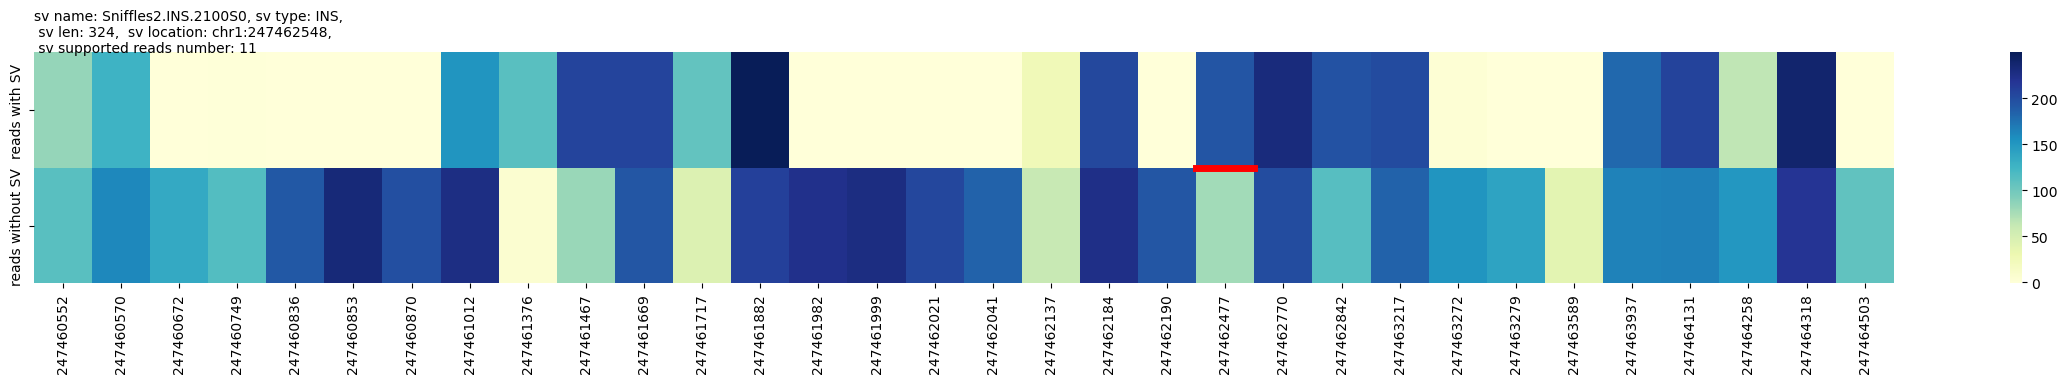

In [25]:
current_sv = hapmap_all_isolated_mosaic_sv_chr1[-1]
cpg_discover_range = 2000
print(f"sv len: {current_sv.sv_len}, sv type: {current_sv.sv_type}, sv location: {current_sv.chromosome}:{current_sv.sv_location_on_ref}, sv supported reads number: {len(current_sv.supported_reads)}")
sv_around_reads_methylation, (search_start, search_end) = compare_different_reads_groups(reads_bam=hapmap_chr1_bam, structural_variant=current_sv, ref_seq=hapmap_reference, cpg_discover_range=cpg_discover_range)

mean_values = {
    int(location): [
        sum(values[0]) / len(values[0]) if len(values[0]) > 0 else -1,
        sum(values[1]) / len(values[1]) if len(values[1]) > 0 else -1
    ]
    for location, values in sv_around_reads_methylation.items()
}
df = pandas.DataFrame(mean_values, index=['reads with SV', 'reads without SV'])
plt.figure(figsize=(30,3))
# plt.plot([search_start, search_end], [0, 0], color='b', linestyle=':')  # Draw a line from (4.5, 2) to (6.5, 4)

ax = seaborn.heatmap(df, fmt=".2f", cmap="YlGnBu")
ax.text(y=0, x=0, s = f"sv name: {current_sv.sv_name}, sv type: {current_sv.sv_type}, \n sv len: {current_sv.sv_len},  sv location: {current_sv.chromosome}:{current_sv.sv_location_on_ref}, \n sv supported reads number: {len(current_sv.supported_reads)}")

# plt.xticks(rotation=45)
xmin_value = get_cloest_value_perc(list(mean_values.keys()), search_start+cpg_discover_range)
xmax_value = get_cloest_value_perc(list(mean_values.keys()), search_end-cpg_discover_range)
if xmax_value == xmin_value: 
    xmax_value = xmin_value + 1/len(mean_values.keys())
plt.axhline(y=1, xmin= xmin_value, xmax = xmax_value, color='red',lw=5)

In [61]:
cpg_discover_range = 1000000
with PdfPages('sv_gc_std_mean.pdf') as pdf:
    for current_sv in tqdm(hapmap_all_isolated_mosaic_sv_chr1):
    # current_sv = hapmap_all_isolated_mosaic_sv_chr1[1]
    
        meth_dict_around_sv = get_base_modification_dictionary(hapmap_chr1_bam, hapmap_reference, 'chr1', (current_sv.sv_location_on_ref-cpg_discover_range, current_sv.sv_location_on_ref+cpg_discover_range))
        mean_dict = {}
        std_dict = {}
        for (cpg_loc, cpg_value_list) in meth_dict_around_sv.items():
            if len(cpg_value_list[0]) > 5:
                
                normalized_methylation_list = [i/255 for i in cpg_value_list[0]]
                methylated_intensity = len([i for i in cpg_value_list[0] if i >= 255*0.66])
                # unmethylated_intensity = cpg_value_list[1] - methylated_intensity
                # m_value = numpy.log2(methylated_intensity / unmethylated_intensity)
                normalized_methylation_list = [i/255 for i in cpg_value_list[0]]
                # std_dict.update({cpg_loc:m_value})
                mean_dict.update({cpg_loc:numpy.mean(normalized_methylation_list)})
                # std_dict.update({})
                # std_dict.update({cpg_loc:numpy.std(normalized_methylation_list) / numpy.mean(normalized_methylation_list)})
                std_dict.update({cpg_loc:numpy.std(normalized_methylation_list)})
        std_df = pandas.DataFrame(list(std_dict.items()), columns=['CpG location', 'Coefficient'])
        mean_df = pandas.DataFrame(list(mean_dict.items()), columns=['CpG location', 'Mean'])
        
        # Calculate the rolling mean
        window_size = 500  # Size of the moving window
        std_df['Smoothed'] = std_df['Coefficient'].rolling(window=window_size).mean()
        mean_df['Smoothed'] = mean_df['Mean'].rolling(window=window_size).mean()
        
        plt.figure(figsize=(30,5))
        ax = seaborn.lineplot(data=std_df, x='CpG location', y='Smoothed')
        # ax = seaborn.lineplot(data=mean_df, x='CpG location', y='Smoothed')
        ax = seaborn.scatterplot(data=mean_df, x='CpG location', y='Smoothed', alpha=0.01, color='red')
        
        kde = scipy.stats.gaussian_kde(mean_df['CpG location'], bw_method=0.1)
        x_densities = kde(mean_df['CpG location'])
        # Normalize the density so it scales nicely on the plot, adjust factor as needed
        # scale_factor = max(y) / max(x_densities)
        scaled_density = x_densities * 1000000
        plt.plot(mean_df['CpG location'], scaled_density, label='Density', color='red')
        
        ax.text(y=0.5, x=current_sv.sv_location_on_ref, s = f"sv name: {current_sv.sv_name}, sv type: {current_sv.sv_type}, \n sv len: {current_sv.sv_len},  sv location: {current_sv.chromosome}:{current_sv.sv_location_on_ref}, \n sv supported reads number: {len(current_sv.supported_reads)}")
        plt.axvline(x=current_sv.sv_location_on_ref, color='red')
        pdf.savefig()
        plt.close()

100%|██████████| 25/25 [15:31<00:00, 37.27s/it]


In [29]:
std_df

,CpG location,Coefficient
0,246462561,0.226245
1,246462576,0.100391
2,246462583,0.092492
3,246462807,0.358471
4,246463143,0.269289
...,...,...
22526,248461028,0.480517
22527,248461102,0.234681
22528,248461112,0.301323
22529,248462047,0.260413


In [611]:
# current_sv = hapmap_all_isolated_mosaic_sv_chr1[4]
cpg_discover_range = 50000

with PdfPages('hapmap_filtered_sv_methylation_std_plots.pdf') as pdf:
    for current_sv in tqdm(hapmap_all_isolated_mosaic_sv_chr1):
        meth_dict_around_sv = get_base_modification_dictionary(hapmap_chr1_bam, hapmap_reference, 'chr1', (current_sv.sv_location_on_ref-cpg_discover_range, current_sv.sv_location_on_ref+cpg_discover_range))
        std_dict = {}
        for (cpg_loc, cpg_value_list) in meth_dict_around_sv.items():
            if len(cpg_value_list[0]) > 5:
                # methylated_intensity = len([i for i in cpg_value_list[0] if i >= 255*0.66])
                # non_methylated_intensity = cpg_value_list[1] - methylated_intensity
                # m_value = np.log2(methylated_intensity / unmethylated_intensity)
                normalized_methylation_list = [i/255 for i in cpg_value_list[0]]
                # std_dict.update({cpg_loc:m_value})
                # std_dict.update({cpg_loc:numpy.std(normalized_methylation_list) / numpy.mean(normalized_methylation_list)})
                std_dict.update({cpg_loc:numpy.std(normalized_methylation_list)})
        std_df = pandas.DataFrame(list(std_dict.items()), columns=['CpG location', 'Coefficient'])
        plt.figure(figsize=(30,5))
        ax = seaborn.lineplot(data=std_df, x='CpG location', y='Coefficient')
        ax.text(y=8, x=current_sv.sv_location_on_ref, s = f"sv name: {current_sv.sv_name}, sv type: {current_sv.sv_type}, \n sv len: {current_sv.sv_len},  sv location: {current_sv.chromosome}:{current_sv.sv_location_on_ref}, \n sv supported reads number: {len(current_sv.supported_reads)}")
        plt.axvline(x=current_sv.sv_location_on_ref, color='red')
        pdf.savefig()
        plt.close()

100%|██████████| 25/25 [00:45<00:00,  1.80s/it]


In [604]:
import numpy as np

def calculate_m_value(methylated_intensity, unmethylated_intensity):
    # Prevent division by zero
    unmethylated_intensity = np.where(unmethylated_intensity == 0, np.finfo(float).eps, unmethylated_intensity)
    
    # Calculate M value as the log2 ratio of methylated to unmethylated intensities
    m_value = np.log2(methylated_intensity / unmethylated_intensity)
    
    return m_value

# Example usage
methylated_intensity = 100  # Example intensity for methylated alleles
unmethylated_intensity = 100  # Example intensity for unmethylated alleles

m_value = calculate_m_value(methylated_intensity, unmethylated_intensity)
print(f"M value: {m_value}")


M value: 0.0
